In [74]:
import pandas as pd
import numpy as np

In [75]:
df=pd.read_csv("./bengaluru_house_prices.csv")

In [76]:
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [78]:
df1=df[['location','size','total_sqft','bath','price']]

In [79]:
df1.isna().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [80]:
df1.dropna(inplace=True)

C:\Users\pruth\AppData\Local\Temp\ipykernel_23316\3614008390.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.dropna(inplace=True)


In [81]:
df1['size']=df1['size'].apply(lambda x : int(x.split()[0]))

C:\Users\pruth\AppData\Local\Temp\ipykernel_23316\2279046362.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['size']=df1['size'].apply(lambda x : int(x.split()[0]))


In [82]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13246 non-null  object 
 1   size        13246 non-null  int64  
 2   total_sqft  13246 non-null  object 
 3   bath        13246 non-null  float64
 4   price       13246 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 620.9+ KB


In [83]:
df1.total_sqft.unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [84]:
import re
def sqft(x):
    a=re.sub("[^0-9]"," ",x)
    if len(a.split())>1:
        a=a.split()
        return (int(a[0])+int(a[1]))/2   
    else:
        return float(a)

In [85]:
df1['total_sqft']=df1.total_sqft.apply(lambda x : sqft(x))

C:\Users\pruth\AppData\Local\Temp\ipykernel_23316\2560713796.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['total_sqft']=df1.total_sqft.apply(lambda x : sqft(x))


In [86]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13246 non-null  object 
 1   size        13246 non-null  int64  
 2   total_sqft  13246 non-null  float64
 3   bath        13246 non-null  float64
 4   price       13246 non-null  float64
dtypes: float64(3), int64(1), object(1)
memory usage: 620.9+ KB


In [87]:
df1=df1[df1.bath < df1['size']+1]

In [88]:
df1.total_sqft.sum()/df1['size'].sum()

np.float64(536.8708413425994)

In [89]:
df1=df1[df1.total_sqft/df1['size']>400]

In [90]:
# df1.groupby('location').count()

In [91]:
a=df1.groupby('location',sort='desc')['location'].count()

In [92]:
a=a[a>20]

In [93]:
df1.location=df1.location.apply(lambda x :x if x in a else 'other')

In [94]:
df.location.count()

np.int64(13319)

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

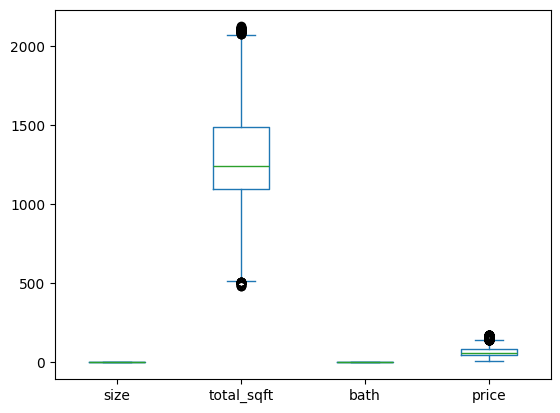

In [101]:
df1.plot(kind='box')

In [97]:
q1=df1.bath.quantile(0.25)
q3=df1.bath.quantile(0.75)
iqr=q3-q1
low=q1-1.5*iqr
upper=q3+1.5*iqr

df1=df1[(df1.bath<upper) & (df1.bath>low)]

In [98]:
q1=df1.price.quantile(0.25)
q3=df1.price.quantile(0.75)
iqr=q3-q1
low=q1-1.5*iqr
upper=q3+1.5*iqr
df1=df1[(df1.price<upper) & (df1.price>low)]

In [99]:
q1=df1['size'].quantile(0.25)
q3=df1['size'].quantile(0.75)
iqr=q3-q1
low=q1-1.5*iqr
upper=q3+1.5*iqr
df1=df1[(df1['size']<upper) & (df1['size']>low)]

In [100]:
q1=df1.total_sqft.quantile(0.25)
q3=df1.total_sqft.quantile(0.75)
iqr=q3-q1
low=q1-1.5*iqr
upper=q3+1.5*iqr
df1=df1[(df1.total_sqft<upper) & (df1.total_sqft>low)]

In [73]:
df1

,location,size,total_sqft,bath,price


In [102]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor

In [103]:
x,xt,y,yt=train_test_split(df1[['location','size','total_sqft','bath']],df1['price'],random_state=42,test_size=0.20)

In [104]:
scaler=StandardScaler()
x_t=pd.DataFrame(scaler.fit_transform(x[['size','total_sqft','bath']]),columns=scaler.get_feature_names_out())
xt_t=pd.DataFrame(scaler.transform(xt[['size','total_sqft','bath']]),columns=scaler.get_feature_names_out())

In [105]:
import sklearn
from sklearn.preprocessing import LabelEncoder
lable=LabelEncoder()
x_t['location']=lable.fit_transform(x['location'])
xt_t['location']=lable.transform(xt['location'])

In [106]:
xt_t

,size,total_sqft,bath,location
0,-0.566751,-0.343898,-0.361124,119
1,-2.240550,-0.927319,-2.192698,116
2,-0.566751,-0.107288,-0.361124,95
3,-0.566751,-0.927319,-0.361124,57
4,1.107047,1.779108,1.470450,47
...,...,...,...,...
1830,-0.566751,-0.603196,-0.361124,119
1831,-0.566751,-0.765258,-0.361124,119
1832,-2.240550,-2.385873,-2.192698,119
1833,-0.566751,-0.360104,-0.361124,98


In [107]:
knn=KNeighborsRegressor(n_neighbors=5)
knn.fit(x_t, y)
pred=knn.predict(xt_t)
mean_squared_error(yt,pred)

np.float64(419.49970540381474)

In [181]:
# ============================================================
# 1. IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ============================================================
# 2. LOAD DATA
# ============================================================
# Change file name/path if needed
df = pd.read_csv("./bengaluru_house_prices.csv")

print("Original shape:", df.shape)
print(df.head())

# ============================================================
# 3. BASIC CLEANING
#    - Drop unused columns
#    - Handle missing values
# ============================================================
# Columns like 'area_type', 'society', 'availability' are often not used
df = df.drop(['area_type', 'society', 'availability'], axis=1)

# Drop rows where key columns are missing
df = df.dropna(subset=['location', 'size', 'total_sqft', 'bath', 'price'])

print("After dropping NA:", df.shape)

# ============================================================
# 4. FEATURE: BHK from "size" (e.g. '2 BHK', '4 Bedroom')
# ============================================================
def extract_bhk(x):
    """
    Extracts the first number from size string.
    Examples:
        '2 BHK' -> 2
        '4 Bedroom' -> 4
    """
    x = str(x)
    nums = re.findall(r'\d+', x)
    if len(nums) > 0:
        return int(nums[0])
    else:
        return None

df['bhk'] = df['size'].apply(extract_bhk)
df = df.dropna(subset=['bhk'])

print("Sample size & bhk:")
print(df[['size', 'bhk']].head())

# ============================================================
# 5. CLEAN total_sqft (handle ranges, text, etc.)
# ============================================================
def clean_sqft(x):
    """
    Cleans total_sqft values:
      - '1200 - 1500' -> average = 1350
      - '2100Sq. Meter' -> 2100 (just numeric part)
      - '1200' -> 1200
      - If no numeric, returns None
    """
    x = str(x)
    # Keep only digits and spaces; replace everything else with space
    a = re.sub("[^0-9 ]", " ", x)
    nums = a.split()

    if len(nums) > 1:       # e.g. '1200 - 1500'
        return (float(nums[0]) + float(nums[1])) / 2.0
    elif len(nums) == 1:    # e.g. '1200'
        return float(nums[0])
    else:
        return None

df['total_sqft_num'] = df['total_sqft'].apply(clean_sqft)
df = df.dropna(subset=['total_sqft_num'])

print("Sample sqft cleaning:")
print(df[['total_sqft', 'total_sqft_num']].head())

# ============================================================
# 6. REMOVE OUTLIERS: sqft per BHK (very small flats)
#    Rule: at least 300 sqft per BHK
# ============================================================
df = df[df['total_sqft_num'] / df['bhk'] >= 300]
print("After sqft-per-bhk filter:", df.shape)

# ============================================================
# 7. CLEAN LOCATION & GROUP RARE LOCATIONS
# ============================================================
df['location'] = df['location'].apply(lambda x: x.strip())
location_stats = df['location'].value_counts()

# Locations that appear <= 10 times -> 'other'
rare_locations = location_stats[location_stats <= 10].index
df['location'] = df['location'].apply(
    lambda x: 'other' if x in rare_locations else x
)

print("Unique locations after grouping:", df['location'].nunique())
print(df['location'].value_counts().head())

# ============================================================
# 8. PRICE PER SQFT & OUTLIER REMOVAL BY LOCATION
# ============================================================
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft_num']

def remove_pps_outliers(df):
    """
    Removes properties whose price_per_sqft lies outside
    (mean - std) to (mean + std) for each location.
    """
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        filtered = subdf[(subdf.price_per_sqft > (m - st)) & 
                         (subdf.price_per_sqft <= (m + st))]
        df_out = pd.concat([df_out, filtered], ignore_index=True)
    return df_out

df = remove_pps_outliers(df)
print("After price_per_sqft outlier removal:", df.shape)

# ============================================================
# 9. REMOVE BHK OUTLIERS
#    Idea: In same location, a higher BHK should not be cheaper
#          per sqft than lower BHK (beyond some tolerance)
# ============================================================
def remove_bhk_outliers(df):
    exclude_indices = np.array([])

    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }

        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk - 1)
            if stats and stats['count'] > 5:
                # remove those BHK apartments whose price_per_sqft is less than
                # mean price_per_sqft of (bhk-1) apartments
                bad_indices = bhk_df[bhk_df.price_per_sqft < stats['mean']].index.values
                exclude_indices = np.append(exclude_indices, bad_indices)

    return df.drop(exclude_indices, axis='index')

df = remove_bhk_outliers(df)
print("After BHK outlier removal:", df.shape)

# (Optional) Drop price_per_sqft if you don't want it as feature
# df = df.drop('price_per_sqft', axis=1)

# ============================================================
# 10. FINAL DATAFRAME FOR MODEL
# ============================================================
df_model = df[['location', 'total_sqft_num', 'bath', 'bhk', 'price']].copy()

X = df_model.drop('price', axis=1)
y = df_model['price']

# ============================================================
# 11. TRAIN-TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ============================================================
# 12. PREPROCESSING: ONE-HOT ENCODE 'location'
# ============================================================
categorical_cols = ['location']
numeric_cols = ['total_sqft_num', 'bath', 'bhk']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

# ============================================================
# 13. MODEL: LINEAR REGRESSION PIPELINE
# ============================================================
linreg_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

linreg_pipe.fit(X_train, y_train)
y_pred = linreg_pipe.predict(X_test)

# ============================================================
# 14. EVALUATION
# ============================================================
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

print("\n=== Linear Regression Performance ===")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

# ============================================================
# 15. TRAIN FINAL MODEL ON FULL DATA (OPTIONAL, FOR DEPLOYMENT)
# ============================================================
linreg_pipe.fit(X, y)   # retrain on all data for best final model

# ============================================================
# 16. HELPER: PREDICT PRICE FOR NEW INPUT
# ============================================================
def predict_price(location, sqft, bath, bhk):
    """
    Predicts price in Lakh for a given configuration.
    Uses the trained linreg_pipe.
    """
    data = pd.DataFrame([{
        'location': location,
        'total_sqft_num': sqft,
        'bath': bath,
        'bhk': bhk
    }])
    return linreg_pipe.predict(data)[0]

# Example usage:
example_pred = predict_price("Whitefield", 1200, 2, 2)
print("\nExample prediction (Whitefield, 1200 sqft, 2 bath, 2 bhk):", example_pred)


Original shape: (13320, 9)
              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2      NaN       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4      NaN       1200   2.0      1.0   51.00  
After dropping NA: (13246, 6)
Sample size & bhk:
        size  bhk
0      2 BHK    2
1  4 Bedroom    4
2      3 BHK    3
3      3 BHK    3
4      2 BHK    2
Sample sqft cleaning:
  total_sqft  total_sqft_num
0       

C:\Users\pruth\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
